<a href="https://colab.research.google.com/github/msminhchile0808-del/MPG-Dataset-Analysis-and-Visualization/blob/main/MPG_Dataset_Analysis_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Create a DataFrame that contains the following properties and statistics of all features in the MPG.csv dataset:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Week 2/mpg.csv')
df

,MPG,Cylinders,Displacement,Horse_Power,Weight,Acceleration,Model_Year,Name
0,18.0,8,307.0,130,3504,12.0,70,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,ford torino
...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86,2790,15.6,82,ford mustang gl
388,44.0,4,97.0,52,2130,24.6,82,vw pickup
389,32.0,4,135.0,84,2295,11.6,82,dodge rampage
390,28.0,4,120.0,79,2625,18.6,82,ford ranger


In [ ]:
import pandas as pd

mpg_df = pd.DataFrame(columns=df.columns, index=['Count', 'Unique', 'Type', 'Min', '25%', 'Median', '75%', 'Max', 'Mode', 'Mean', 'Std', 'Skew', 'Kurt'])
mpg_df.loc['Type'] = list(df.dtypes)
mpg_df.loc['Count'] = list(df.count())
mpg_df.loc['Unique'] = list(df.nunique())
mpg_df.loc['Mode'] = list(df.mode().values[0])
mpg_df.loc['Min'] = list(df.min())

# Calculate statistics only for numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
mpg_df.loc['25%', numeric_cols] = list(df[numeric_cols].quantile(.25))
mpg_df.loc['Median', numeric_cols] = list(df[numeric_cols].median())
mpg_df.loc['75%', numeric_cols] = list(df[numeric_cols].quantile(.75))
mpg_df.loc['50%', numeric_cols] = list(df[numeric_cols].quantile(.5))
mpg_df.loc['Max', numeric_cols] = list(df[numeric_cols].max())
mpg_df.loc['Mean', numeric_cols] = list(df[numeric_cols].mean())
mpg_df.loc['Std', numeric_cols] = list(df[numeric_cols].std())
mpg_df.loc['Skew', numeric_cols] = list(df[numeric_cols].skew())
mpg_df.loc['Kurt', numeric_cols] = list(df[numeric_cols].kurt())

mpg_df

,MPG,Cylinders,Displacement,Horse_Power,Weight,Acceleration,Model_Year,Name
Count,392,392,392,392,392,392,392,392
Unique,127,5,81,93,346,95,13,301
Type,float64,int64,float64,int64,int64,float64,int64,object
Min,9.0,3,68.0,46,1613,8.0,70,amc ambassador brougham
25%,17.0,4.0,105.0,75.0,2225.25,13.775,73.0,NaN
Median,22.75,4.0,151.0,93.5,2803.5,15.5,76.0,NaN
75%,29.0,8.0,275.75,126.0,3614.75,17.025,79.0,NaN
Max,46.6,8.0,455.0,230.0,5140.0,24.8,82.0,NaN
Mode,13.0,4.0,97.0,150.0,1985.0,14.5,73.0,amc matador
Mean,23.445918,5.471939,194.41199,104.469388,2977.584184,15.541327,75.979592,NaN


In [ ]:
print(mpg_df.loc['Skew','MPG'])

0.45709232306041025


In [ ]:
print(mpg_df.loc['Std', 'Weight'])

849.4025600429496


In [ ]:
print(mpg_df.loc['Mean', 'Weight'])

2977.5841836734694


In [ ]:
print(mpg_df.loc['Unique', 'Name'])

301


In [ ]:
print(mpg_df.loc['Mode','Displacement'])

97.0


In [ ]:
# Get the statistics from the mpg_df DataFrame

m = round(mpg_df.loc['Mean','Acceleration'], 2)
std = round(mpg_df.loc['Std','Acceleration'], 2)
s = round(mpg_df.loc['Skew','Acceleration'], 2)
k = round(mpg_df.loc['Kurt','Acceleration'], 2)

print(m, std, s, k)


15.54 2.76 0.29 0.44


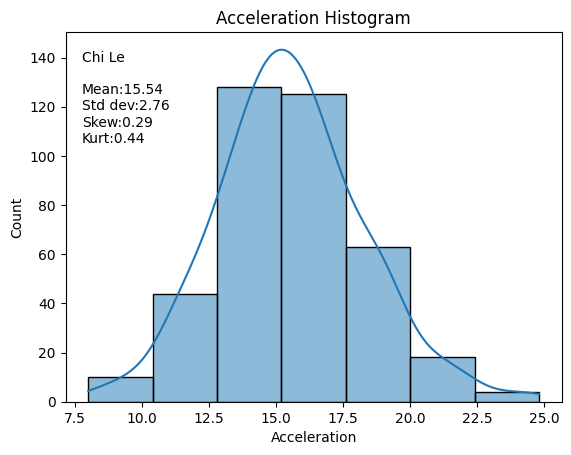

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

text = 'Chi Le' + '\n' + '\n' + 'Mean:'+ str(m) + '\n' + 'Std dev:' + str(std) + '\n' + 'Skew:' + str(s) + '\n' + 'Kurt:' + str(k)

plt.text(.15, .65, text, fontsize=10, transform=plt.gcf().transFigure)
sns.histplot(data=df, x='Acceleration', kde=True, bins=int(round(df.Acceleration.count()**(1/3), 0)))
plt.title('Acceleration Histogram')
plt.xlabel('Acceleration')
plt.ylabel('Count')
plt.savefig('Acceleration Histogram.png', dpi=200)
plt.show()

In [ ]:
bins_count = int(round(df.Acceleration.count()**(1/3), 0))
print(bins_count)

7


7. Create a stacked plot (histogram with a boxplot) using the Seaborn package
Import the correct libraries you will need: seaborn, pandas, and pyplot (from matplotlib).
* You should create a boxplot that has cylinders as the x-axis and acceleration as the y-axis. Adjust sizes so that it looks clean and readable.
* Build a histogram for Acceleration that is divided by different numbers of Cylinders, but only include cars with 4 and 8 cylinders. You may consider reviewing the chapter on how to filter DataFrames for how to do this.
* HINT: consider using the orient="" parameter of the Seaborn .boxplot() object to make this look right. See documentation: https://seaborn.pydata.org/generated/seaborn.boxplot.html
* Embed your full name somewhere in the visualization.
* It should look something like the image below. But again, the exact style details are not important unless it is specified above.



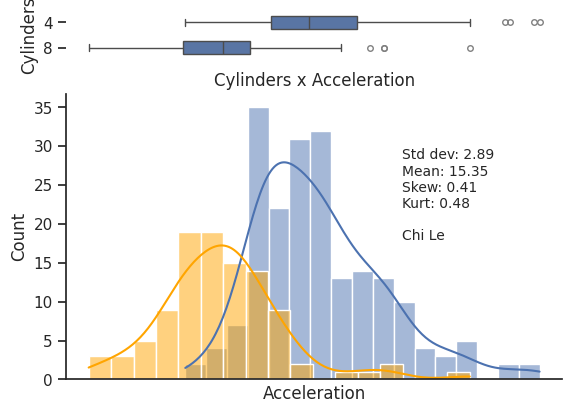

In [ ]:
#reduce df to only 4 & 8 cylinder engines
df1 = df[df['Cylinders'] == 4]
df2 = df[df['Cylinders'] == 8]

# combine both dataframes into 1 df
combo_df = pd.concat([df1, df2], axis=0)

# rename df
df = combo_df

# generate sub plot with 2 rows
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

# plot style
sns.set(style="ticks")

#box plot style
flierprops = dict(marker='o', markersize=4, markerfacecolor='none', linestyle='none', markeredgecolor='gray')
#boxplot                                                   here is where we use the boxplot style from before
sns.boxplot(x=df.Acceleration, y=df.Cylinders, orient="h",ax=ax_box, fliersize=4, width=0.50, linewidth=1, flierprops=flierprops)

#generate distplot
sns.histplot(df[df['Cylinders']== 4].Acceleration, kde=True, ax=ax_hist, bins=int(round(df.Acceleration.count()**(1/2))))
sns.histplot(df[df['Cylinders']== 8].Acceleration, kde=True, ax=ax_hist, bins=int(round(df.Acceleration.count()**(1/2))), color='orange')


# get string of stats again
text =  'Std dev: ' + str(round(df.Acceleration.std(), 2)) + '\n'
text += 'Mean: ' + str(round(df.Acceleration.mean(), 2)) + '\n'
text += 'Skew: ' + str(round(df.Acceleration.skew(), 2)) + '\n'
text += 'Kurt: ' + str(round(df.Acceleration.kurt(), 2))+ '\n\n'
text += 'Chi Le'

#put the text on the graph
ax_hist.text(0.65, 0.4, text, fontsize=10, transform=plt.gcf().transFigure)

ax_box.set(xticks=[]) # no x ticks for boxplot
ax_box.set_xlabel('') # no x label for boxplot
plt.title('Cylinders x Acceleration') # title for distplot
plt.ylabel('Count') # y label for distplot
sns.despine(ax=ax_hist) # remove lines from top & right of distribution plot
sns.despine(ax=ax_box, left=True, bottom=True) # remove lines from top & right of boxplot

# save
plt.savefig('stacked_plot.png', dpi=100) # Must appear before plt.show()